
La fuerza de lorentz de manera mas general se describe por su formula 

$$\textbf{F}=\int\left(\rho\textbf{E} +\textbf{J}\times\textbf{B}\right) \,dV$$

considerando $\rho\approx0$


$$\textbf{F}=\int\textbf{J}\times\textbf{B} \,dV$$

Esta es una integral de volumen donde se integra todo el volumen y al final lo que queda es la corriente $I$ donde:

$$|\textbf{J}|=J=\frac{I}{A}$$

Por esta formula se observa que si $A$ aumenta, lo que cambia es la densidad de corriente $\textbf{J}$ y por lo tanto al integrar la fuerza en un volumen de no estas modificando la fuerza.



Si se considera que $\frac{\partial \textbf{J}}{\partial t}=0$ y $\nabla \cdot\textbf{J}=0$, es decir $\textbf{J}$ es constante temporalmente y espacialmente. Se puede reducir la fuerza de lorentz a la expression:

En coordenadas cilíndricas 
$$dV=dA dz=rdrd\phi dz$$
$$\textbf{J}=J\hat{\textbf{z}}$$

$$\textbf{F}=\int\textbf{J}\times\textbf{B}\quad dV=\textbf{F}=J\int\hat{\textbf{z}}\times\textbf{B}\,dr\,rd\phi\,dz$$

Por ley de ampere podemos calcular el campo magnético considerando el estado quasiestatico

$$\nabla \times \textbf{B}=\mu_0 \textbf{J'}\Rightarrow  \boxed{\textbf{B}=\frac{\mu_0 I'}{2\pi r'} \mathbf{\hat{{\Phi}}'}} $$


Sustituyendo

$$\textbf{F}=J\iiint\hat{\textbf{z}}\times \hat{\phi'}  \frac{\mu_0 I'}{2\pi r'} \quad a^2  d\phi dz$$


integrando para el área transversal , es decir la base $r dr d\phi$, de 0 al radio del cable $(a)$
El producto cruz de $\hat{z}\times \hat{\phi'}=-\hat{r}$
$$\textbf{F}=J\iiint\hat{\textbf{z}}\times \hat{\phi'}  \frac{\mu_0 I'}{2\pi r'} \quad r dr d\phi dz$$

observamos que aparece la corriente $ J A=Ja^2 \pi=I$ 
$$\textbf{F}=J \frac{a^2}{2} 2\pi\int\hat{\textbf{z}}\times \mathbf{\hat{\Phi}'}  \frac{\mu_0 I'}{2\pi r'}   dz= -\frac{\mu_0 I I' l}{2\pi r'} \mathbf{\hat{r}'}  $$

Y por lo tanto la magnitud de la fuerza $F=\textbf{F}$ esta dado por

$$\boxed{F=\frac{\mu_0 I I' l}{2\pi r'} }$$

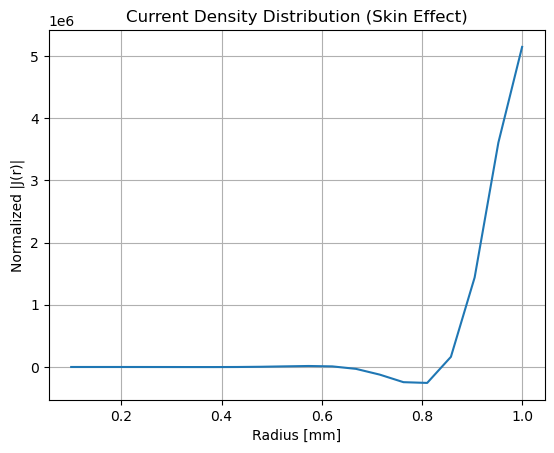

In [325]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn  # Bessel function of the first kind, order 0
from mpl_toolkits.mplot3d import Axes3D

# Parameters
f = 1e6  # frequency [Hz]
mu = 4*np.pi*1e-7  # permeability of copper ~ vacuum
sigma = 5.8e7  # conductivity of copper [S/m]
omega = 2 * np.pi * f
k = np.sqrt(1j * omega * mu * sigma)
a = 1e-3  # wire radius [m]

# Radial positions
N=20
rs = np.linspace(0.0001, a, N)
phi = np.linspace(0, 2*np.pi, N)
zs= np.linspace(0, 3, N)  # Length of the wire

I0 = spherical_jn(0, k*rs, derivative=False)
I1 = spherical_jn(1, k*a, derivative=False)
I=2
J1=I*np.real(k*I0*np.exp(0)/(I1*2*np.pi*a))
# Normalize
#J /= np.max(np.abs(J))

# Plot
plt.plot(rs * 1e3, J1)
plt.xlabel("Radius [mm]")
plt.ylabel("Normalized |J(r)|")
plt.title("Current Density Distribution (Skin Effect)")
plt.grid(True)
plt.show()


In [326]:
dr=np.diff(rs)[0]
#dr[0]=dr[0]/2
#dr[-1]=dr[-1]/2
I=sum(dr*(J1*2*np.pi*rs)[0:-1])
I

1.3092966285366636

In [327]:

phi1 = np.linspace(0.0001, 2*np.pi,N)
zs1= np.linspace(0, 3, N)  # Length of the wire


M=20
xss= np.linspace(-2*a, 2*a, M)
yss= xss
rss = np.linspace(a, 2*a, M)
phi = np.linspace(0.0001, 2*np.pi,M)
zs= np.linspace(0, 3, M)  # Length of the wire


xs=rss*np.cos(phi)
ys=rss*np.sin(phi)

Rs, Phi, Zp = np.meshgrid(rs,phi1, zs1, indexing='ij') #r'
Xp= Rs * np.cos(Phi)  # X coordinates   
Yp = Rs * np.sin(Phi)  # Y coordinates
do=np.diff(phi)[0]
dz=np.diff(zs)[0]



Rss, Phi1, z = np.meshgrid(rss,phi, zs, indexing='ij') #r
x=Rss * np.cos(Phi1)  # X coordinates
y = Rss * np.sin(Phi1)  # Y coordinates


x,y,z=np.meshgrid(xss,yss, zs, indexing='ij') #r

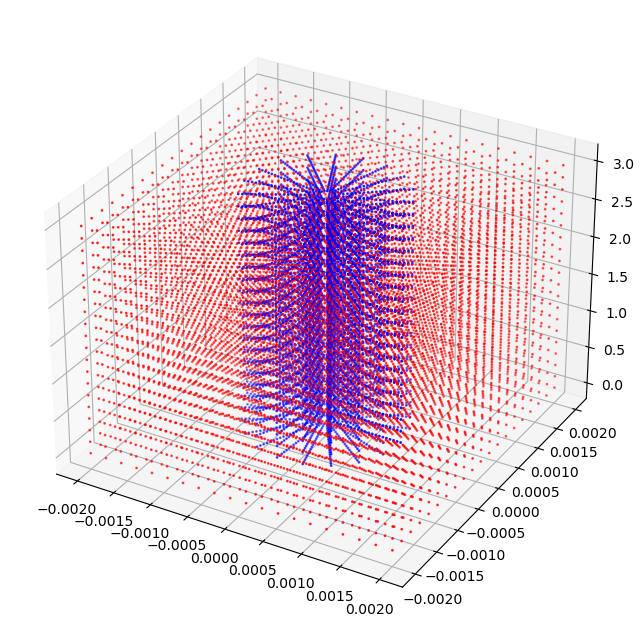

In [328]:
figure = plt.figure(figsize=(10, 8))
ax = figure.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='r', s=1)
ax.scatter(Xp, Yp, Zp, c='b', s=1)



$$\textbf{f}=\textbf{J}(r',t)\times \textbf{B}(r',t)$$

$$\textbf{F}=\int{\textbf{f}} dV$$

In [329]:
def J(X,Y,t):
    rr=np.sqrt(X**2+Y**2)
    omega=50 #Hz
    I0 = spherical_jn(0, k*rr, derivative=False)
    I1 = spherical_jn(1, k*a, derivative=False)
    I=2
    J1=I*np.real(k*I0/(I1*2*np.pi*a)*np.exp(1j*omega*t))  
    J2 = np.nan_to_num(J1, nan=0.0, posinf=0.0, neginf=0.0)

    return  np.stack((J2*0, J2*0, J2), axis=-1) 

In [330]:
np.min(J(Xp,Yp,0))

-256089.27347073072

In [331]:
(Xp).min()

-0.0009863699649097395

(-0.002, 0.002)

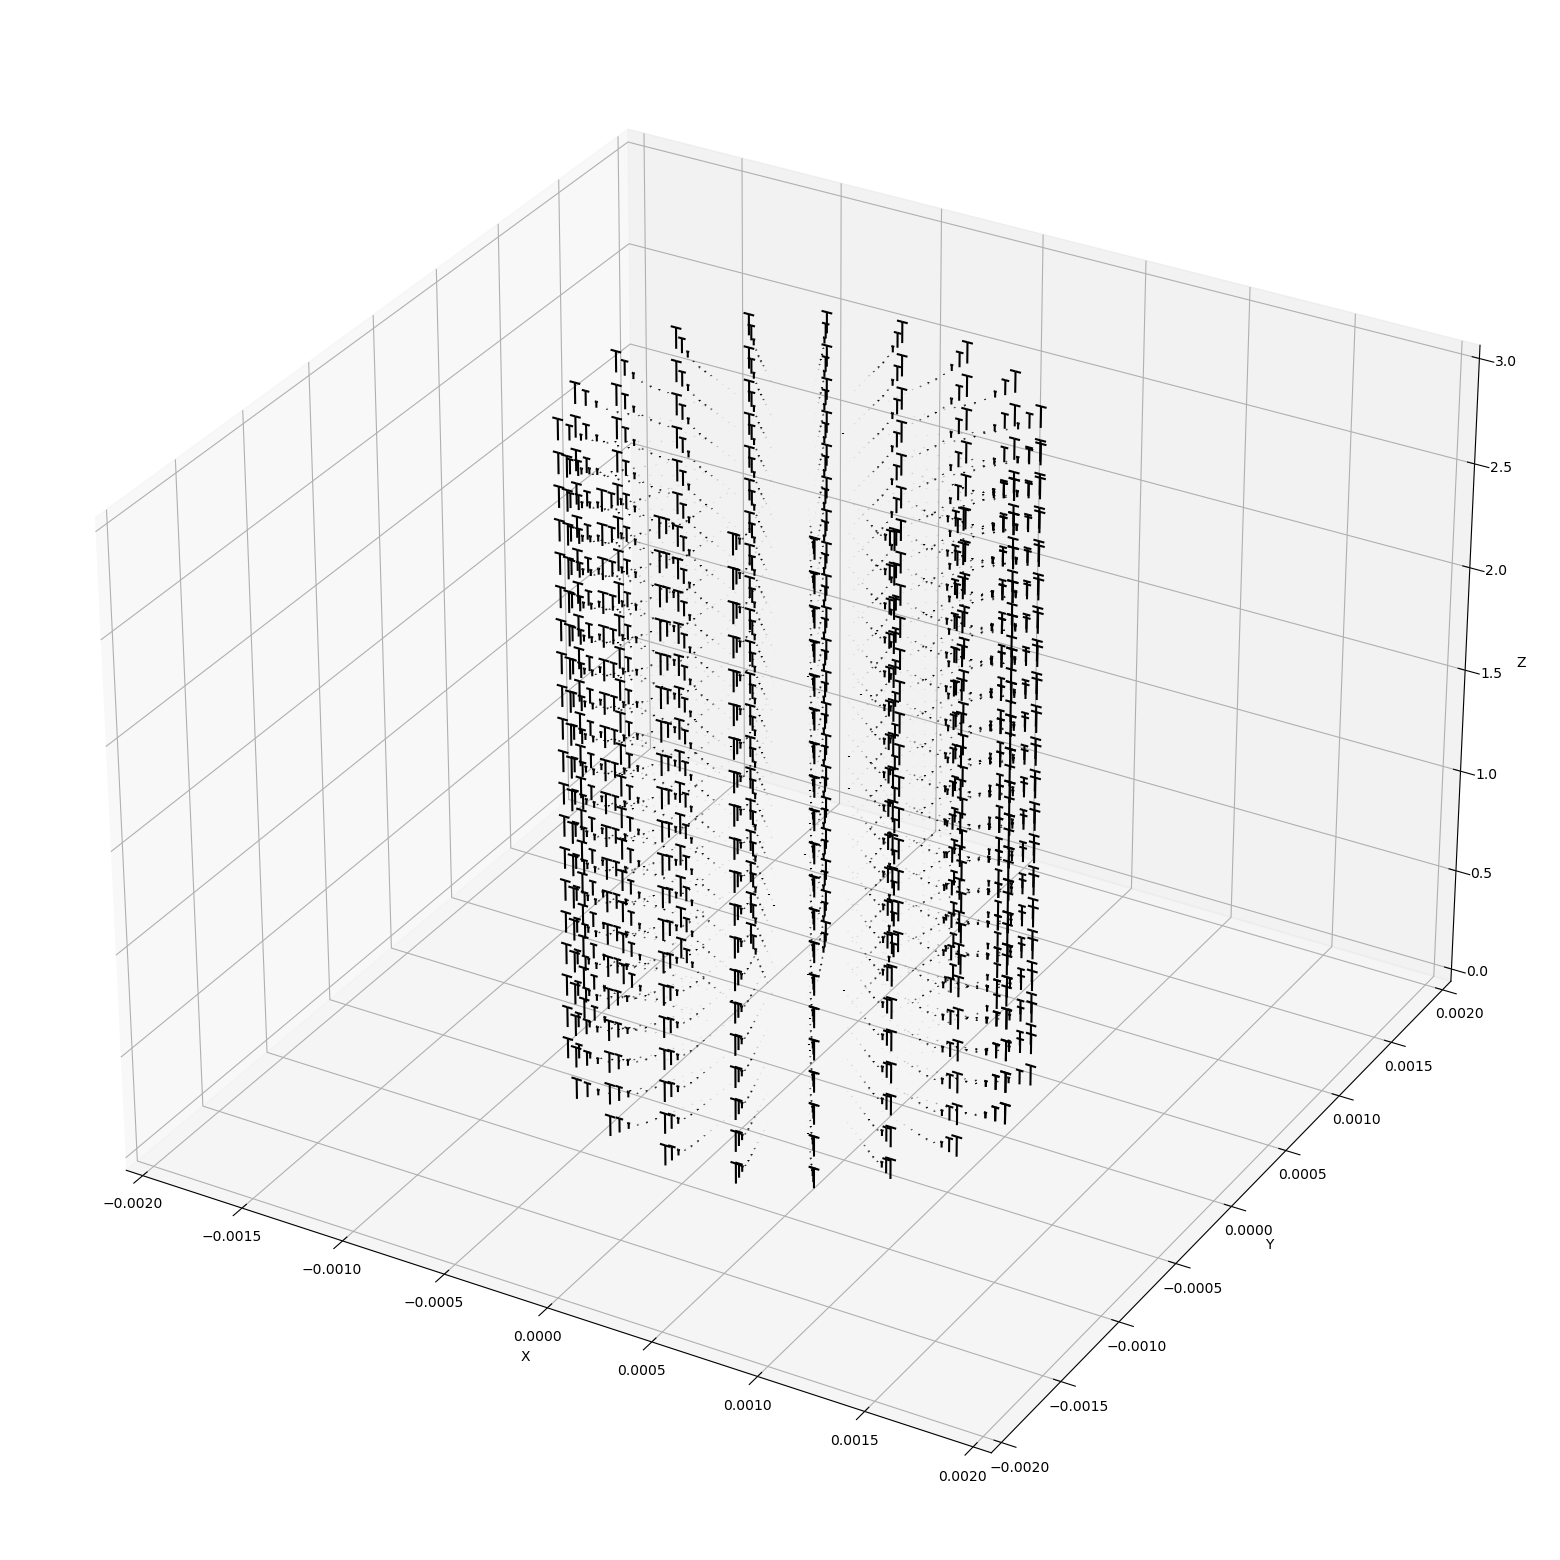

In [332]:
ax = plt.figure(figsize=(20,20)).add_subplot(projection='3d')
JJ=J(Xp,Yp,t=0)
ax.quiver(Xp, Yp, Zp, JJ[:, :,:, 2]*0, JJ[:, : ,:, 2]*0, JJ[:, : ,:, 2]/np.max(JJ),color='k',length=0.1, normalize=False,arrow_length_ratio=0.001,pivot='tail',cmap='jet')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.xlim(-2*a,2*a)
plt.ylim(-2*a,2*a)

$$\mathbf{B}(\mathbf{r}, t)=-\frac{\mu_0}{4 \pi} \int\left[\frac{\mathbf{r}-\mathbf{r}^{\prime}}{\left|\mathbf{r}-\mathbf{r}^{\prime}\right|^3} \times \mathbf{J}\left(\mathbf{r}^{\prime}, t_r\right)\right]d^3 r'.$$

In [333]:
def B(x,y,z,X,Y,Z,t):
    rp=np.stack((X,Y,Z), axis=-1)
    BB = np.zeros(np.shape(np.stack((x,y,z), axis=-1)), dtype=np.complex128)
    #NN = np.zeros((len(X), len(Y), len(Z), 3), dtype=np.complex128)

    for i in range(len(x)):
        for j in range(len(y)):
            for k in range(len(z)):              
                mu0 =1e-7#/(4*np.pi)# 4 * np.pi * 1e-7  # permeability of free space
                r =  np.array([x[i,j,k], y[i,j,k], z[i,j,k]])  # Position vector of the point where B is calculated
                R=(r-rp)
                RR=np.linalg.norm(R, axis=-1, keepdims=False)  # Calculate the distance vector
                RR[RR == 0] = np.inf  # Avoid division by zero
                RR1=1/RR**3
                RRR=np.stack((RR1,RR1,RR1), axis=-1)
                r1=np.sqrt(X**2+Y**2)
                rr1=np.stack((r1, r1, r1), axis=-1)
                PP=mu0*np.cross(J(X,Y,t),R)*(RRR)*rr1*dr*do*dz
                
                BB[i,j,k] = np.sum(PP,axis=(0,1,2))
                
    #BB1=BB*           #B = (mu0 / (4 * np.pi)) * (I / RR) * np.cross(R, [0, 0, 1])
    return np.nan_to_num(BB, nan=0.0, posinf=0.0, neginf=0.0)

In [334]:
B1=B(x,y,z,Xp,Yp,Zp,t=0)

(-0.002, 0.002)

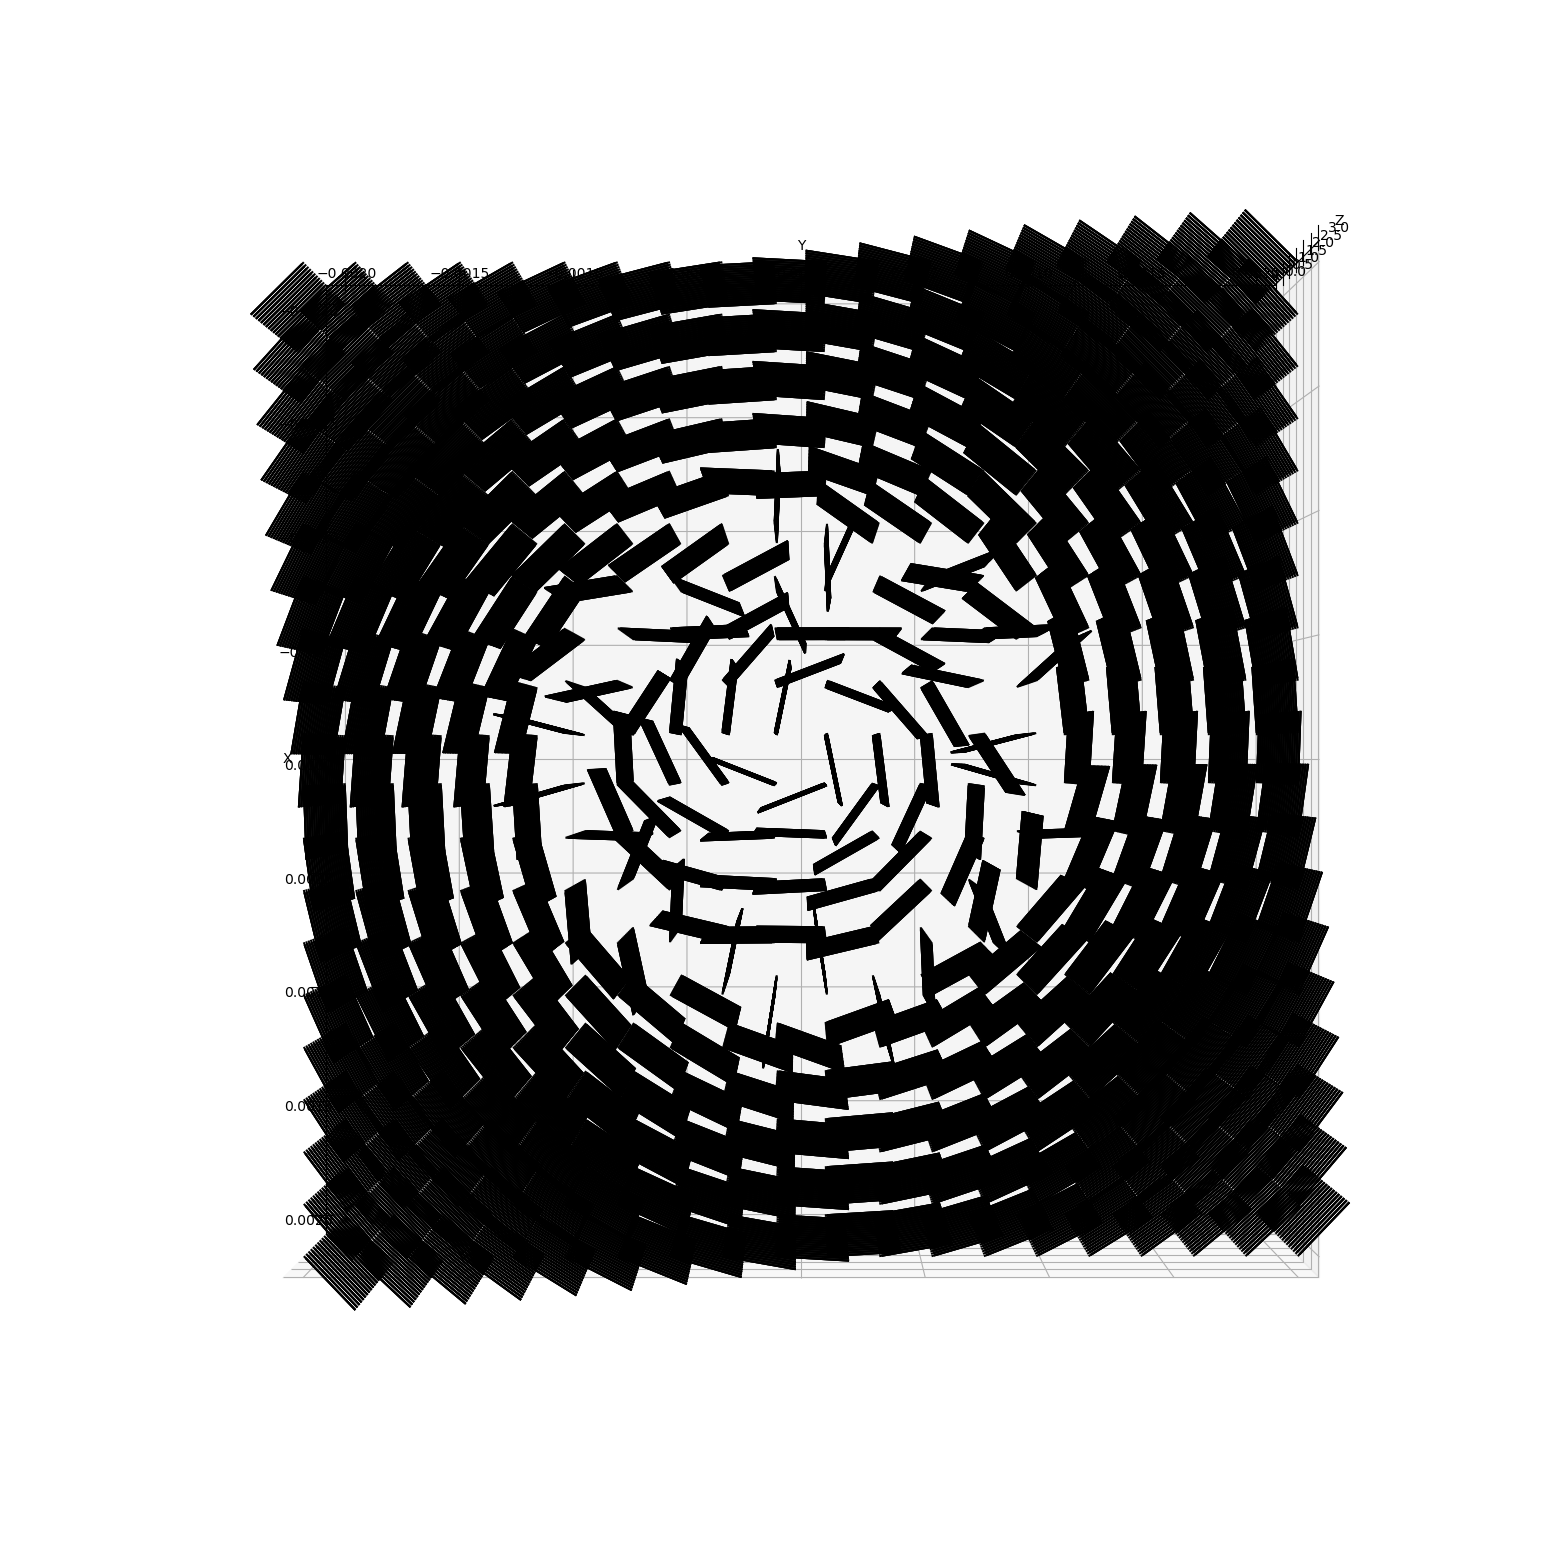

In [337]:
bx = plt.figure(figsize=(20,20)).add_subplot(projection='3d')
bx.quiver(x, y, z, B1[:, :,:, 0], B1[:, : ,:, 1], B1[:, : ,:, 2],color='k',length=0.0003, normalize=True,arrow_length_ratio=1,pivot='tail',cmap='jet')
#bx.set_top_view(True)
bx.view_init(elev=90, azim=0)  # Adjust the view angle
#plt.streamplot(x[:,:,0], y[:,:,0], B1[:, :,0, 0], B1[:, : ,0, 1],color='b')
bx.set_xlabel('X')
bx.set_ylabel('Y')
bx.set_zlabel('Z')
plt.xlim(-2*a,2*a)
plt.ylim(-2*a,2*a)

In [274]:
np.transpose(x[:,:,0])[0:3,:]

array([[-0.002     , -0.00155556, -0.00111111, -0.00066667, -0.00022222,
         0.00022222,  0.00066667,  0.00111111,  0.00155556,  0.002     ],
       [-0.002     , -0.00155556, -0.00111111, -0.00066667, -0.00022222,
         0.00022222,  0.00066667,  0.00111111,  0.00155556,  0.002     ],
       [-0.002     , -0.00155556, -0.00111111, -0.00066667, -0.00022222,
         0.00022222,  0.00066667,  0.00111111,  0.00155556,  0.002     ]])

In [275]:
np.transpose(y[:,:,0])[:,0:3]

array([[-0.002     , -0.002     , -0.002     ],
       [-0.00155556, -0.00155556, -0.00155556],
       [-0.00111111, -0.00111111, -0.00111111],
       [-0.00066667, -0.00066667, -0.00066667],
       [-0.00022222, -0.00022222, -0.00022222],
       [ 0.00022222,  0.00022222,  0.00022222],
       [ 0.00066667,  0.00066667,  0.00066667],
       [ 0.00111111,  0.00111111,  0.00111111],
       [ 0.00155556,  0.00155556,  0.00155556],
       [ 0.002     ,  0.002     ,  0.002     ]])

/usr/lib/python3/dist-packages/matplotlib/streamplot.py:651: ComplexWarning: Casting complex values to real discards the imaginary part
  x = int(xi)
/usr/lib/python3/dist-packages/matplotlib/streamplot.py:652: ComplexWarning: Casting complex values to real discards the imaginary part
  y = int(yi)


TypeError: ufunc 'hypot' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

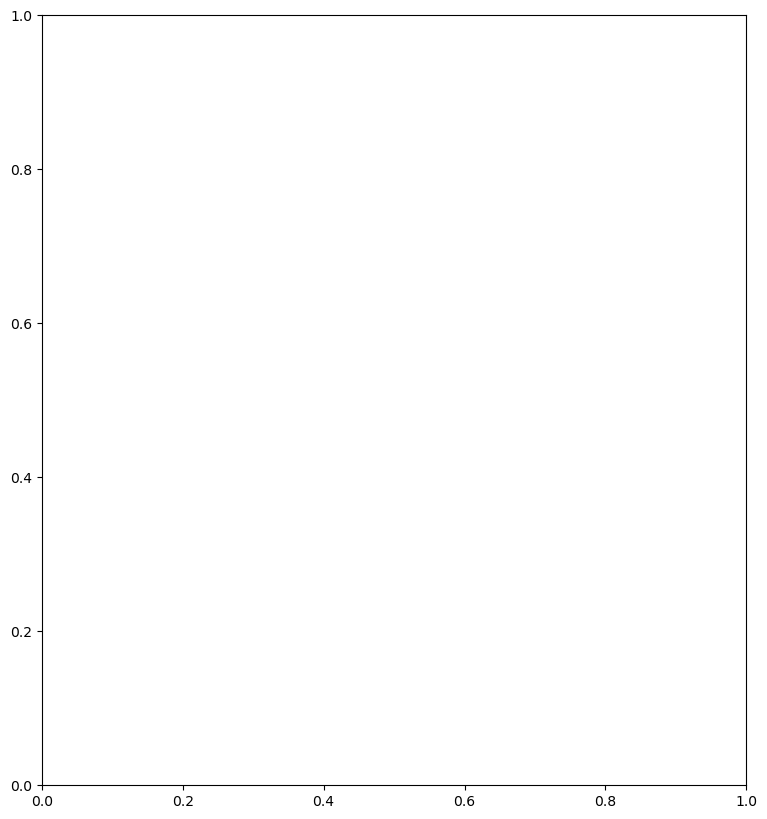

In [277]:
fig = plt.figure(figsize=(20, 10))
ax2d = fig.add_subplot(1, 2, 2)
ax2d.streamplot(np.transpose(x[:,:,0])[0,:],np.transpose(x[:,:,0])[0,:], np.transpose(B1[:, :,0, 0]), np.transpose(B1[:, : ,0, 1]),color='b')
ax2d.set_title(f"Streamplot on z = {z0:.3f}")
ax2d.set_xlabel('X')
ax2d.set_ylabel('Y')
ax2d.set_aspect('equal')

In [105]:
B1.shape

(10, 10, 10, 3)

In [122]:
r1=[1,1,1];
ts=0;
res=np.sum(B(r1,X,Y,Z,ts))
np.shape(res)

()

In [123]:
res

(7.645073711270012e+163+0j)

In [ ]:
def jj():
    return np.cross()

In [19]:
import numpy as np

# Define constant vector r1
r1 = np.array([1, 1, 1])  # e.g., a=1, b=2, c=3


nx=10
ny=10
nz=10
x0=0
y0=x0
z0=x0

xf=1
yf=xf
zf=xf
# Define volume
x = np.linspace(x0, xf, nx)
y = np.linspace(y0, yf, ny)
z = np.linspace(z0, zf, nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Stack into position vector field r(x, y, z)
r_field = np.stack((X, Y, Z), axis=-1)  # shape: (nx, ny, nz, 3)

# Compute r1 × r(x, y, z) directly with broadcasting
cross_field = np.cross(r_field,r1)  # shape: (nx, ny, nz, 3)


In [20]:
cross_field

array([[[[ 0.        ,  0.        ,  0.        ],
         [-0.11111111,  0.11111111,  0.        ],
         [-0.22222222,  0.22222222,  0.        ],
         ...,
         [-0.77777778,  0.77777778,  0.        ],
         [-0.88888889,  0.88888889,  0.        ],
         [-1.        ,  1.        ,  0.        ]],

        [[ 0.11111111,  0.        , -0.11111111],
         [ 0.        ,  0.11111111, -0.11111111],
         [-0.11111111,  0.22222222, -0.11111111],
         ...,
         [-0.66666667,  0.77777778, -0.11111111],
         [-0.77777778,  0.88888889, -0.11111111],
         [-0.88888889,  1.        , -0.11111111]],

        [[ 0.22222222,  0.        , -0.22222222],
         [ 0.11111111,  0.11111111, -0.22222222],
         [ 0.        ,  0.22222222, -0.22222222],
         ...,
         [-0.55555556,  0.77777778, -0.22222222],
         [-0.66666667,  0.88888889, -0.22222222],
         [-0.77777778,  1.        , -0.22222222]],

        ...,

        [[ 0.77777778,  0.        , -0

In [9]:
np.shape(r_field)

(10, 10, 10, 3)

In [24]:
np.shape(r_field[:,:,:,2])

(10, 10, 10)